In [2]:
import tensorflow as tf 
import numpy as np

In [3]:
fashionMnist = tf.keras.datasets.fashion_mnist.load_data()
(XTrainFull, yTrainFull), (XTest, yTest) = fashionMnist

In [4]:
XTrain, yTrain = XTrainFull[:55000], yTrainFull[:-5000]
XValid, yValid =  XTrainFull[55000:], yTrainFull[55000:]
XValid.shape, yValid.shape, XTrain.shape, yTrain.shape

((5000, 28, 28), (5000,), (55000, 28, 28), (55000,))

In [5]:
XTrain = XTrain.astype("float32") / 255.0
XValid = XValid.astype("float32") / 255.0
XTest = XTest.astype("float32") / 255.0

In [6]:
import numpy as np

print("XTrain NaN:", np.isnan(XTrain).any())
print("XTrain Inf:", np.isinf(XTrain).any())

print("XValid NaN:", np.isnan(XValid).any())
print("XValid Inf:", np.isinf(XValid).any())

print("Min:", XTrain.min())
print("Max:", XTrain.max())

XTrain NaN: False
XTrain Inf: False
XValid NaN: False
XValid Inf: False
Min: 0.0
Max: 1.0


In [7]:
import matplotlib.pyplot as plt

def displayImage(img):
    plt.imshow(img, cmap="binary")
    plt.axis("off")
    plt.show()
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Image Index: 7793. 
Product name: Coat. 


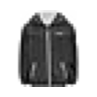

In [8]:
randomInt = np.random.randint(0, 55000)
print(f"Image Index: {randomInt}. \nProduct name: {class_names[yTrain[randomInt]]}. ")
plt.figure(figsize=(1,1))
displayImage(XTrain[randomInt])

In [9]:
np.random.randint(1, 5, dtype=np.uint16)
2+np.random.rand(28, 28)

array([[2.7800315 , 2.32381981, 2.22970402, 2.3479636 , 2.33011783,
        2.33139137, 2.39866986, 2.79238488, 2.22322214, 2.12079611,
        2.29908948, 2.79409776, 2.60212613, 2.280447  , 2.79503394,
        2.24340922, 2.82102684, 2.23128003, 2.92322662, 2.62205357,
        2.84615523, 2.48006278, 2.02494559, 2.95280596, 2.63942506,
        2.64740709, 2.20142965, 2.0985034 ],
       [2.64242902, 2.68429908, 2.74668443, 2.69099531, 2.83702642,
        2.18274071, 2.72604376, 2.7067585 , 2.61209567, 2.85029688,
        2.54600505, 2.65538646, 2.59134111, 2.06880929, 2.70415152,
        2.0491462 , 2.08946926, 2.16866446, 2.45704685, 2.48648342,
        2.1369776 , 2.91658844, 2.07022685, 2.25986613, 2.10857481,
        2.50601221, 2.89018557, 2.46835923],
       [2.72596296, 2.17656654, 2.66263881, 2.78313415, 2.67562051,
        2.45909378, 2.66015584, 2.89384585, 2.74060598, 2.11608701,
        2.27675999, 2.15965406, 2.50605627, 2.20689118, 2.6414499 ,
        2.60460568, 2.3054

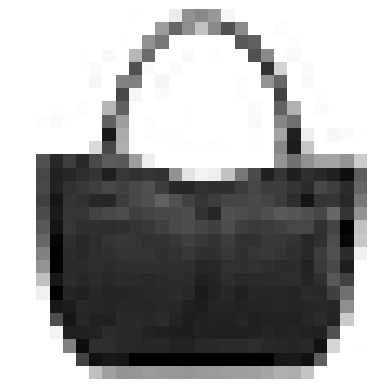

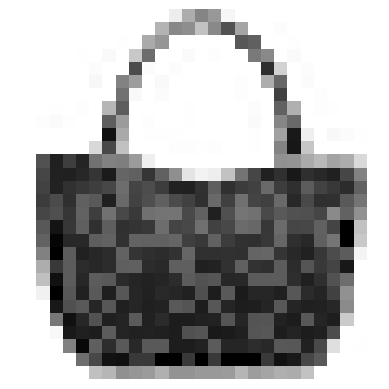

(55000, 28, 28)

In [10]:
displayImage(XTrain[100])
cusOne = XTrain.copy()
cusOne = np.clip(cusOne*np.clip((np.random.randint(0, 3, XTrain.shape, dtype=np.uint8)), 0.77, 1.025), 0, 1)
displayImage(cusOne[100])
cusOne.shape

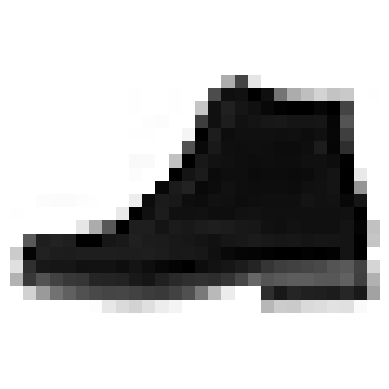

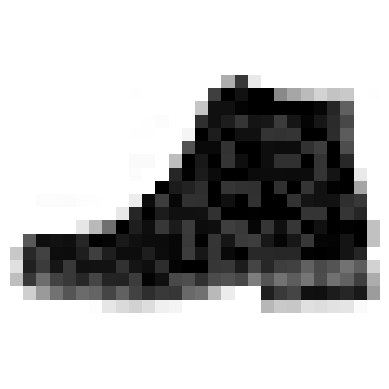

In [11]:
displayImage(XTrain[42])
cusTwo = XTrain.copy()
cusTwo = np.clip((cusTwo* np.clip(np.random.randint(0, 3, XTrain.shape, dtype=np.uint8), 0.85, 1.07)), 0, 1)
displayImage(cusTwo[42])

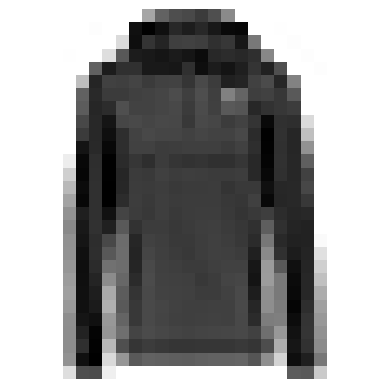

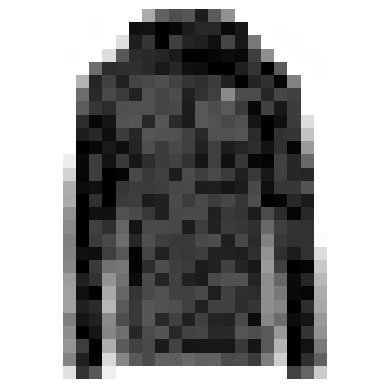

In [12]:
displayImage(XTrain[24])
cusThree = XTrain.copy()
cusThree = np.clip((cusThree* np.clip(np.random.randint(0, 3, XTrain.shape, dtype=np.uint8), 0.93, 1.15)), 0, 1)
displayImage(cusThree[24])

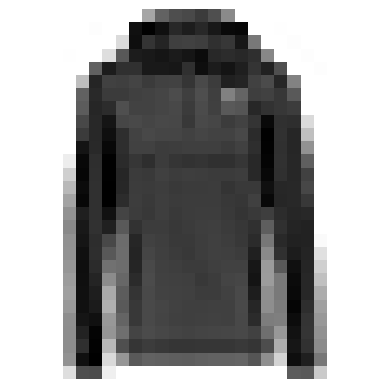

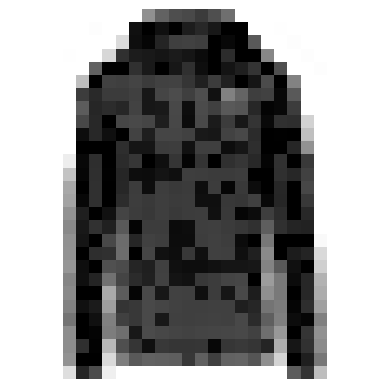

In [13]:
displayImage(XTrain[24])
cusFour = XTrain.copy()
cusFour = np.clip((cusFour* np.clip(np.random.randint(0, 3, XTrain.shape, dtype=np.uint8), 0.9975, 1.23)), 0, 1)
displayImage(cusFour[24])

In [14]:
XTrainExtended = np.concatenate((XTrain, cusOne, cusThree, cusTwo, cusFour), axis=0)
XTrainExtended.shape

(275000, 28, 28)

In [15]:
yTrainExtended = np.concatenate((yTrain, yTrain, yTrain, yTrain, yTrain), axis=0)
yTrainExtended.shape

(275000,)

In [16]:
tf.keras.utils.set_random_seed(67)
#tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)), #Input layer
    tf.keras.layers.Flatten(), #Input layer
    tf.keras.layers.Dense(400, activation=tf.keras.activations.relu), #Hidden layer 1
    tf.keras.layers.Dense(200, activation=tf.keras.activations.relu), #Hidden layer 2
    tf.keras.layers.Dense(100, activation=tf.keras.activations.relu), #Hidden layer 3
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax) #Output layer
])

model.summary()

E0000 00:00:1787776878.997322   12349 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415,310 (1.58 MB)

 Trainable params: 415,310 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy, optimizer=tf.keras.optimizers.SGD(learning_rate=0.0007), metrics=[
    tf.keras.metrics.SparseCategoricalAccuracy
])

In [17]:
history = model.fit(XTrain, yTrain, validation_data=(XValid, yValid), epochs=60, batch_size=20)

Epoch 1/60
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.4079 - sparse_categorical_accuracy: 0.5903 - val_loss: 0.9151 - val_sparse_categorical_accuracy: 0.7030
Epoch 2/60
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.8123 - sparse_categorical_accuracy: 0.7264 - val_loss: 0.7074 - val_sparse_categorical_accuracy: 0.7684
Epoch 3/60
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.6775 - sparse_categorical_accuracy: 0.7787 - val_loss: 0.6185 - val_sparse_categorical_accuracy: 0.7940
Epoch 4/60
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 3s 994us/step - loss: 0.6071 - sparse_categorical_accuracy: 0.8005 - val_loss: 0.5662 - val_sparse_categorical_accuracy: 0.8088
Epoch 5/60
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 3s 999us/step - loss: 0.5629 - sparse_categorical_accuracy: 0.8121 - val_loss: 0.5318 - val_sparse_categorical_accuracy: 0.8212
Epoch 6/60
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 3s 977us/step - loss: 0.5327 - sparse_categorical_accuracy: 0.8203 - val_loss: 0.5075 - val_sparse_categorical_acc

In [18]:
import pandas as pd
historyDF = pd.DataFrame(history.history)
historyDF

,loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy
0,1.407925,0.590273,0.915100,0.7030
1,0.812256,0.726382,0.707389,0.7684
2,0.677503,0.778655,0.618461,0.7940
3,0.607062,0.800509,0.566151,0.8088
4,0.562946,0.812073,0.531812,0.8212
5,0.532742,0.820255,0.507547,0.8286
6,0.510570,0.826545,0.489375,0.8318
7,0.493559,0.831455,0.475099,0.8350
8,0.479870,0.835236,0.463410,0.8386
9,0.468485,0.838309,0.453722,0.8416


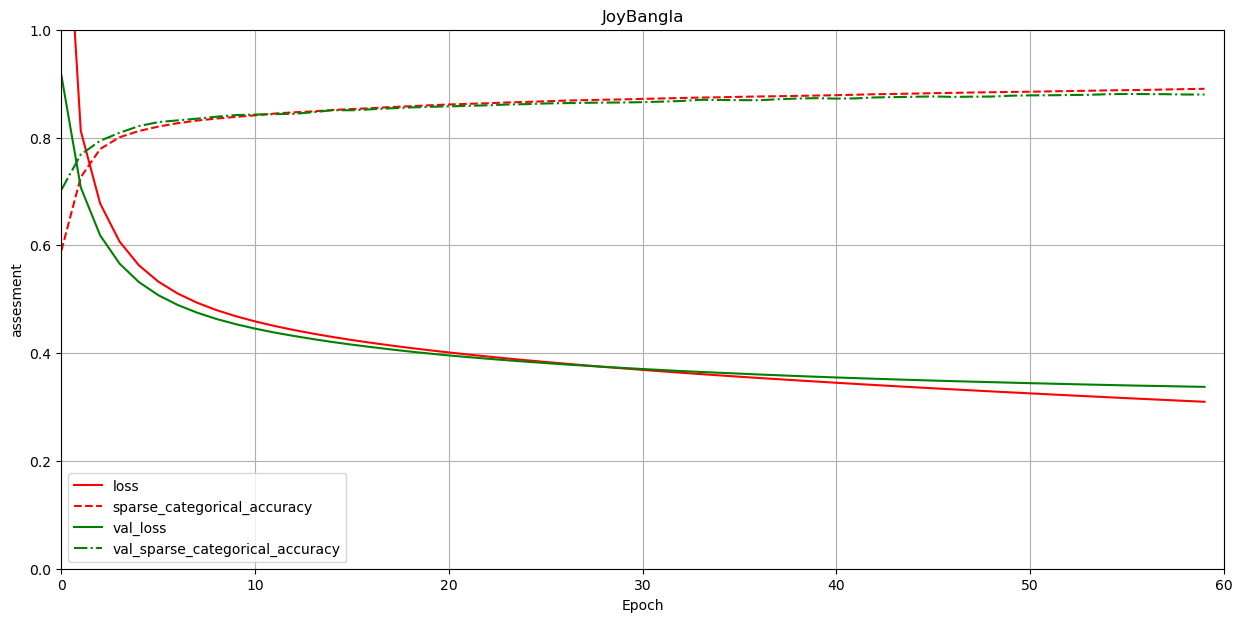

In [19]:
historyDF.plot(xlim=[0, 60], ylim=[0,1],figsize=(15, 7), grid=True, xlabel="Epoch", ylabel = "assesment", style=["r-", "r--", "g-", "g-."], title="JoyBangla")
plt.show()

In [20]:
model.evaluate(XTest, yTest, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 5s 478us/step - loss: 0.3702 - sparse_categorical_accuracy: 0.8689


[0.3702382445335388, 0.8689000010490417]

In [21]:
modelTwo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(400, activation=tf.keras.activations.relu),
    tf.keras.layers.Dropout(0.45),
    tf.keras.layers.Dense(300, activation=tf.keras.activations.relu),
    tf.keras.layers.Dropout(0.45),
    tf.keras.layers.Dense(300, activation=tf.keras.activations.relu),
    tf.keras.layers.Dropout(0.45),
    tf.keras.layers.Dense(200, activation=tf.keras.activations.relu),
    tf.keras.layers.Dropout(0.45),
    tf.keras.layers.Dense(200, activation=tf.keras.activations.relu),
    tf.keras.layers.Dropout(0.45),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax),
])
modelTwo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │       120,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627,010 (2.39 MB)

 Trainable params: 627,010 (2.39 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
modelTwo.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.007), loss=tf.keras.losses.sparse_categorical_crossentropy, metrics=[
    tf.keras.metrics.SparseCategoricalAccuracy()
])

In [54]:
sample_weights = np.concatenate([
    np.full(len(XTrain), 2.5),      # original
    np.full(len(cusOne), 1.0),      # augmented
    np.full(len(cusTwo), 1.0),      # augmented
    np.full(len(cusThree), 1.0),    # augmented
    np.full(len(cusFour), 1.0)      # augmented
])
sample_weights.shape

(275000,)

In [34]:
XTrainExtendedFull = np.concatenate((XTrainExtended, XValid), axis=0)
XTrainExtendedFull.shape

(280000, 28, 28, 1)

In [35]:
yTrainExtendedFull = np.concatenate((yTrainExtended, yValid), axis=0)
yTrainExtendedFull.shape

(280000,)

In [61]:
historyTwo = modelTwo.fit(XTrainExtendedFull, yTrainExtendedFull, validation_data=(XValid, yValid), epochs=60, batch_size=32)

Epoch 1/60
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0628 - sparse_categorical_accuracy: 0.9800 - val_loss: 0.4659 - val_sparse_categorical_accuracy: 0.9028
Epoch 2/60
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0625 - sparse_categorical_accuracy: 0.9801 - val_loss: 0.4314 - val_sparse_categorical_accuracy: 0.9058
Epoch 3/60
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0588 - sparse_categorical_accuracy: 0.9812 - val_loss: 0.4245 - val_sparse_categorical_accuracy: 0.9072
Epoch 4/60
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0580 - sparse_categorical_accuracy: 0.9815 - val_loss: 0.3985 - val_sparse_categorical_accuracy: 0.9070
Epoch 5/60
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0584 - sparse_categorical_accuracy: 0.9811 - val_loss: 0.3877 - val_sparse_categorical_accuracy: 0.9078
Epoch 6/60
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.0583 - sparse_categorical_accuracy: 0.9813 - val_loss: 0.3771 - val_sparse_categorical_acc

<Axes: >

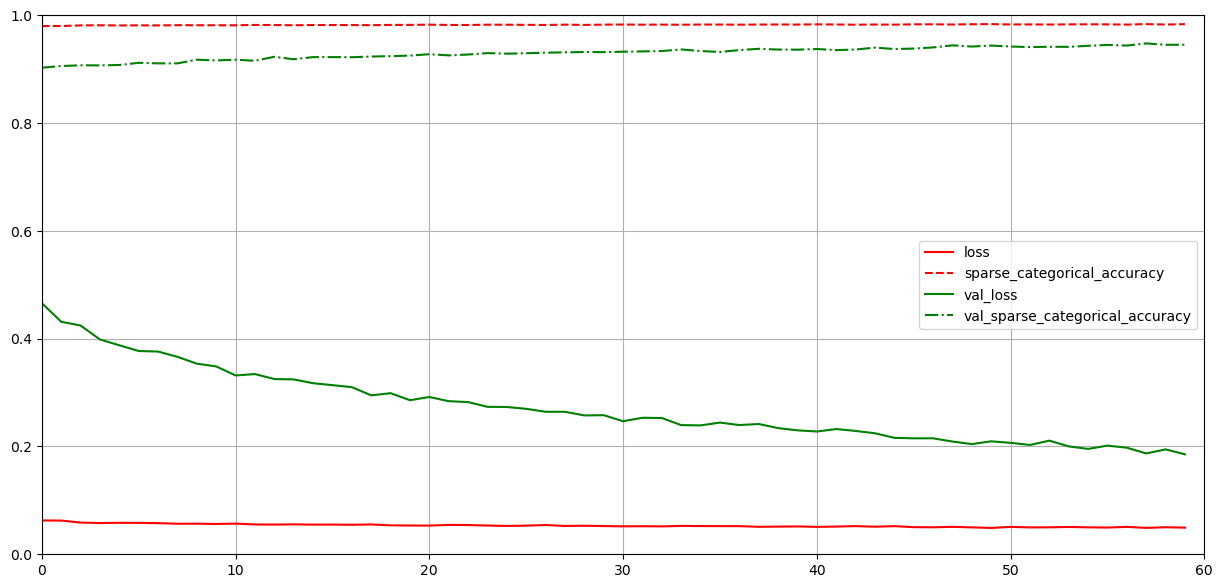

In [62]:
historyTwoDF = pd.DataFrame(historyTwo.history)
historyTwoDF.plot(xlim=[0, 60], ylim=[0,1], grid=True, style=["r-", "r--", "g-", "g-."], figsize=(15, 7))

In [64]:
modelTwo.evaluate(XTest, yTest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.5053 - sparse_categorical_accuracy: 0.9005


[0.5053330063819885, 0.9004999995231628]

In [65]:
modelTwo.save("final_model.keras")

In [66]:
modelTwo.evaluate(XTrain, yTrain)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step - loss: 0.0082 - sparse_categorical_accuracy: 0.9977


[0.00824639480561018, 0.9977454543113708]

In [68]:
modelTwo.evaluate(XTrainExtended, yTrainExtended)

8594/8594 ━━━━━━━━━━━━━━━━━━━━ 7s 790us/step - loss: 0.0080 - sparse_categorical_accuracy: 0.9979


[0.008035950362682343, 0.9979454278945923]

In [134]:

def displayImageS(img):
    plt.figure(figsize=(1, 1))
    plt.imshow(img, cmap="binary")
    plt.axis("off")
    plt.show()

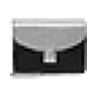

Bag
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Bag


In [143]:
displayImageS(XTest[78])
print(class_names[yTest[78]])
randomYProba = modelTwo.predict(np.expand_dims(XTest[78], axis=0))
index = randomYProba.argmax()
print(class_names[index])

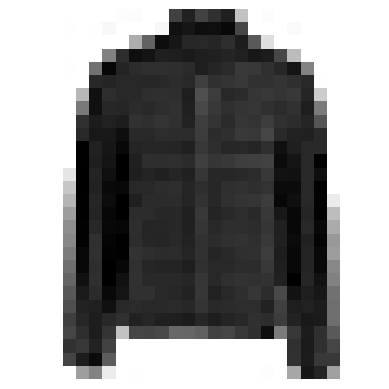

Coat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Coat


In [168]:
rIndex = np.random.randint(0, 10_000, dtype=np.uint16)

displayImage(XTest[rIndex])
print(class_names[yTest[rIndex]])
randomYProba = modelTwo.predict(np.expand_dims(XTest[rIndex], axis=0))
index = randomYProba.argmax()
print(class_names[index])

In [17]:
XTrainExtended = XTrainExtended[..., np.newaxis]
XValid = XValid[..., np.newaxis]
XTest = XTest[..., np.newaxis]
XTrain = XTrain[..., np.newaxis]
XTrainExtended.shape, XValid.shape, XTest.shape, XTrain.shape

((275000, 28, 28, 1),
 (5000, 28, 28, 1),
 (10000, 28, 28, 1),
 (55000, 28, 28, 1))

In [19]:
# --------------------------------------------------
# 2nd Data augmentation
# --------------------------------------------------

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        7.5 / 360.0
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.075,
        width_factor=0.078
    ),

    tf.keras.layers.RandomZoom(
        height_factor=(-0.085, 0.085),
        width_factor=(-0.085, 0.085)
    )
])


# --------------------------------------------------
#  CNN
# --------------------------------------------------

CNNModel = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    augmentation,

    tf.keras.layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])


CNNModel.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,100,682 (4.20 MB)

 Trainable params: 1,100,682 (4.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
CNNModel.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [86]:
sample_weights = np.concatenate([
    np.full(len(XTrain), 1.25),   # original
    np.full(len(cusOne), 1),      # augmented
    np.full(len(cusTwo), 1),      # augmented
    np.full(len(cusThree), 1),    # augmented
    np.full(len(cusFour), 1),     # augmented
])
sample_weights.shape

(275000,)

In [ ]:
history = CNNModel.fit(
    XTrainExtended,
    yTrainExtended,
    epochs=10,
    batch_size=128,
    validation_data = (XValid, yValid),
    sample_weight = sample_weights
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 137ms/step - accuracy: 0.9831 - loss: 0.0483 - val_accuracy: 0.9528 - val_loss: 0.1528
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 137ms/step - accuracy: 0.9822 - loss: 0.0500 - val_accuracy: 0.9590 - val_loss: 0.1331
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 140ms/step - accuracy: 0.9831 - loss: 0.0481 - val_accuracy: 0.9552 - val_loss: 0.1581
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - accuracy: 0.9837 - loss: 0.0477 - val_accuracy: 0.9622 - val_loss: 0.1357
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - accuracy: 0.9829 - loss: 0.0486 - val_accuracy: 0.9634 - val_loss: 0.1230
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - accuracy: 0.9830 - loss: 0.0486 - val_accuracy: 0.9618 - val_loss: 0.1274
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - accuracy: 0.9837 - loss: 0.0460 - val_accuracy: 0.9630 - val_loss: 0.1293
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - accuracy: 0.9830 - loss: 0

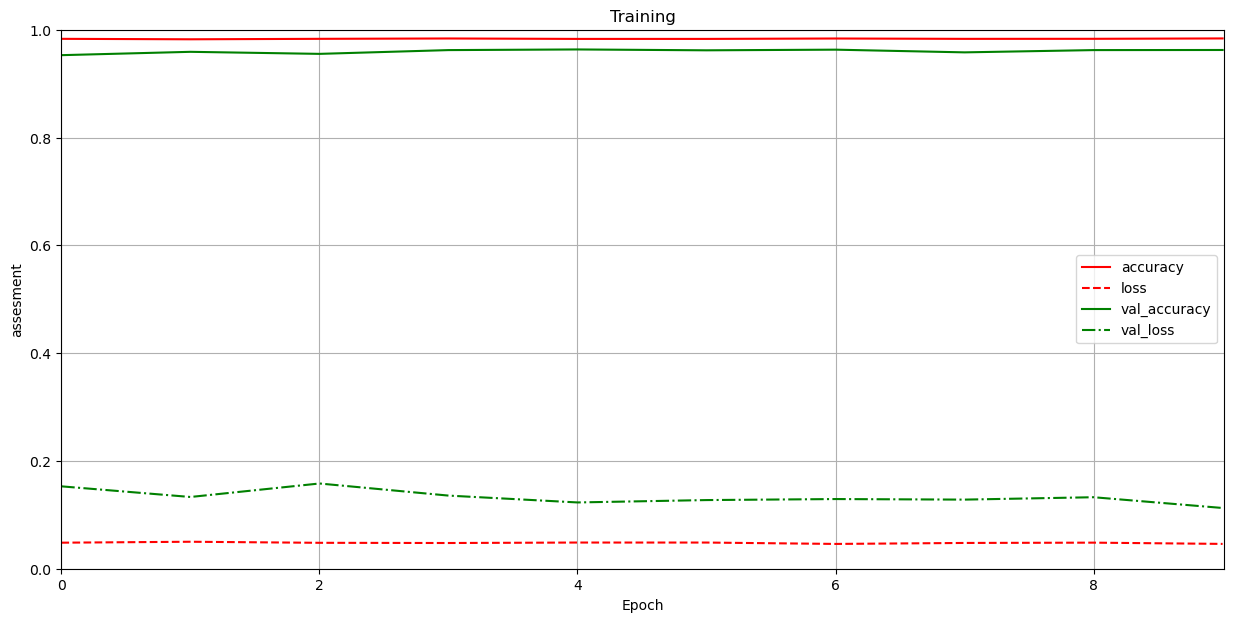

In [83]:
import pandas as pd
historyDF = pd.DataFrame(history.history)
historyDF
historyDF.plot(xlim=[0, 9.01], ylim=[0,1],figsize=(15, 7), grid=True, xlabel="Epoch", ylabel = "assesment", style=["r-", "r--", "g-", "g-."], title="Training")
plt.show()

In [85]:
CNNModel.save("final_cnn_model.keras")